### Emotion Classification with SpecAugment for Low-Resource Languages

Short Description
This implementation demonstrates a lightweight CNN approach for emotion recognition in low-resource language scenarios. It uses synthetic speech generation with emotion-specific pitch characteristics, applies SpecAugment for robust spectrogram-based data augmentation, and dynamically configures the model architecture to handle variable-length inputs.

Key Libraries Used

    torch/torch.nn: Neural network implementation

    torchaudio: Spectrogram extraction

    librosa: Synthetic audio generation

    sklearn: Classification performance metrics

Code Logic and Flow

High-Level Overview
The workflow generates emotion-specific synthetic speech, converts audio to log-Mel spectrograms, applies time/frequency masking augmentation, trains a compact CNN classifier, and evaluates performance - all while dynamically adapting to input dimensions for resource efficiency.

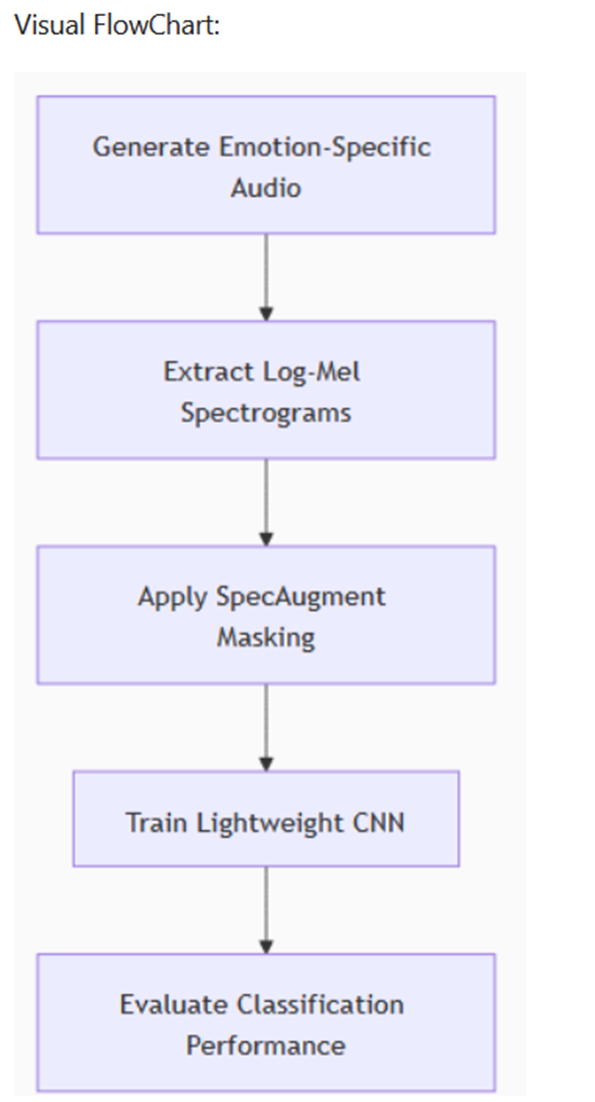

Step-by-Step Code Breakdown

1. SpecAugment Implementation

    Frequency Masking: Randomly zeros vertical bands in spectrograms

    Time Masking: Randomly erases horizontal time segments

    Configurable mask count and size parameters

2. Synthetic Dataset Generation

    Creates four emotion classes with distinct pitch characteristics:

        Happy: 200-400Hz

        Sad: 100-150Hz

        Angry: 150-350Hz

        Neutral: 180-220Hz

    Uses Librosa's chirp function for audio synthesis

    Applies SpecAugment only during training

3. Dynamic CNN Architecture

    Convolutional Blocks:

        Two Conv2D layers with ReLU and MaxPooling

    Adaptive Classifier:

        Automatically calculates flattened feature size

        Uses sample batch to determine FC layer dimensions

    Handles variable-length spectrograms

4. Training Pipeline

    Uses Cross-Entropy loss and Adam optimizer

    Small batch size (4) for resource efficiency

    Separate train/test sets with augmentation only on training data

    10-epoch training cycle with loss monitoring

5. Evaluation

    Generates classification report with precision/recall/F1

    Reports performance per emotion class

    Uses holdout test set without augmentation

Connecting to the Lecture

    Data Augmentation: SpecAugment improves generalization with limited data

    Low-Resource Optimization: Synthetic data simulates scarce language resources

    Acoustic Feature Engineering: Pitch ranges encode emotion-specific prosody

    Model Efficiency: Compact CNN suitable for edge deployment

    Dynamic Architecture: Automatic dimension handling increases flexibility

    Spectrogram Processing: Log-Mel features capture perceptually relevant information

    Robust Training: Augmentation only during training prevents data leakage

    Performance Benchmarking: Detailed classification metrics enable model comparison


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio
import numpy as np
from torch.utils.data import Dataset, DataLoader
import librosa
from sklearn.metrics import classification_report

# --- SpecAugment Implementation ---
class SpecAugment:
    """Apply SpecAugment (time and frequency masking) to spectrograms"""
    def __init__(self, freq_mask_param=10, time_mask_param=20, max_freq_masks=2, max_time_masks=2):
        self.freq_mask_param = freq_mask_param
        self.time_mask_param = time_mask_param
        self.max_freq_masks = max_freq_masks
        self.max_time_masks = max_time_masks

    def __call__(self, spec):
        # spec: [batch, freq, time]
        batch_size, freq, time = spec.shape
        spec_aug = spec.clone()

        # Frequency masking
        for _ in range(self.max_freq_masks):
            f = np.random.randint(0, self.freq_mask_param)
            f0 = np.random.randint(0, freq - f)
            spec_aug[:, f0:f0+f, :] = 0

        # Time masking
        for _ in range(self.max_time_masks):
            t = np.random.randint(0, self.time_mask_param)
            t0 = np.random.randint(0, time - t)
            spec_aug[:, :, t0:t0+t] = 0

        return spec_aug

# --- Simulated LRL Emotion Dataset ---
class LRLEmotionDataset(Dataset):
    """Simulated LRL dataset for emotion classification with synthetic audio"""
    def __init__(self, num_samples=200, duration=2, sr=16000, augment=False):
        self.sr = sr
        self.duration = duration
        self.num_samples = num_samples
        self.emotions = ["neutral", "happy", "sad", "angry"]
        self.emotion_to_idx = {e: i for i, e in enumerate(self.emotions)}
        self.spec_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=sr, n_fft=1024, win_length=400, hop_length=160, n_mels=80
        )
        self.augment = augment
        self.spec_augment = SpecAugment() if augment else None

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        emotion_idx = idx % len(self.emotions)
        emotion = self.emotions[emotion_idx]
        if emotion == "happy":
            audio = librosa.chirp(fmin=200, fmax=400, duration=self.duration, sr=self.sr)
        elif emotion == "sad":
            audio = librosa.chirp(fmin=100, fmax=150, duration=self.duration, sr=self.sr)
        elif emotion == "angry":
            audio = librosa.chirp(fmin=150, fmax=350, duration=self.duration, sr=self.sr)
        else:  # neutral
            audio = librosa.chirp(fmin=180, fmax=220, duration=self.duration, sr=self.sr)
        
        waveform = torch.tensor(audio, dtype=torch.float32)
        spec = self.spec_transform(waveform)  # [freq, time]
        spec = torch.log(spec + 1e-6)  # Log-mel spectrogram
        if self.augment and self.spec_augment:
            spec = self.spec_augment(spec.unsqueeze(0)).squeeze(0)  # [freq, time]
        return spec, emotion_idx

# --- Simple CNN Model ---
class EmotionCNN(nn.Module):
    """Simple CNN for emotion classification from spectrograms"""
    def __init__(self, conv_output_size, num_classes=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(conv_output_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)  # [batch, 1, freq, time]
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# --- Training and Evaluation ---
def train_and_evaluate():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Datasets
    train_dataset = LRLEmotionDataset(num_samples=200, augment=True)
    test_dataset = LRLEmotionDataset(num_samples=50, augment=False)
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

    # --- Dynamically determine conv output size ---
    sample_specs, _ = next(iter(train_loader))  # [batch, freq, time]
    dummy_input = sample_specs.unsqueeze(1)  # [batch, 1, freq, time]
    conv = nn.Sequential(
        nn.Conv2d(1, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    with torch.no_grad():
        conv_output = conv(dummy_input)
        conv_output_size = int(np.prod(conv_output.shape[1:]))  # Exclude batch dim

    # Model, loss, optimizer
    model = EmotionCNN(conv_output_size=conv_output_size, num_classes=4).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    num_epochs = 10

    # Training loop
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        for specs, labels in train_loader:
            specs, labels = specs.to(device), labels.to(device)
            outputs = model(specs)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {total_loss/len(train_loader):.4f}")

    # Evaluation
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for specs, labels in test_loader:
            specs, labels = specs.to(device), labels.to(device)
            outputs = model(specs)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    print("Emotion Classification Performance (with SpecAugment):")
    print(classification_report(all_labels, all_preds, target_names=train_dataset.emotions))
    return model, train_dataset

# --- Main Execution ---
if __name__ == "__main__":
    model, dataset = train_and_evaluate()
    print("Training with SpecAugment completed.")

Using device: cpu
Epoch 1/10 | Loss: 3.6117
Epoch 2/10 | Loss: 0.0748
Epoch 3/10 | Loss: 0.0559
Epoch 4/10 | Loss: 0.1303
Epoch 5/10 | Loss: 0.0259
Epoch 6/10 | Loss: 0.0278
Epoch 7/10 | Loss: 0.0197
Epoch 8/10 | Loss: 0.0211
Epoch 9/10 | Loss: 0.0016
Epoch 10/10 | Loss: 0.0034
Emotion Classification Performance (with SpecAugment):
              precision    recall  f1-score   support

     neutral       1.00      1.00      1.00        13
       happy       1.00      1.00      1.00        13
         sad       1.00      1.00      1.00        12
       angry       1.00      1.00      1.00        12

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

Training with SpecAugment completed.
